<a href="https://colab.research.google.com/github/Daheeyah/Daheeyah/blob/main/jupyter_notebooks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Syntecxhub_Project_Spam_Detection

# IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# LOAD DATASET

In [2]:
import pandas as pd
import zipfile
import os

# Define the path to the zip file
zip_file_path = "/content/sms+spam+collection.zip"
# Define the directory where content should be extracted
extract_dir = "/content/"
# Define the name of the file we expect after extraction
expected_file_name = "SMSSpamCollection"
full_extracted_path = os.path.join(extract_dir, expected_file_name)

# Check if the zip file exists
if os.path.exists(zip_file_path):
    # Unzip the file if it hasn't been unzipped already
    if not os.path.exists(full_extracted_path):
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print(f"'{zip_file_path}' unzipped to '{extract_dir}'.")
    else:
        print(f"'{expected_file_name}' already exists in '{extract_dir}'. Skipping unzip.")

    # Now read the CSV
    df = pd.read_csv(
        full_extracted_path,
        sep="\t",
        header=None,
        names=["label", "message"]
    )

    print("DataFrame head:")
    print(df.head())
else:
    print(f"Error: Zip file '{zip_file_path}' not found.")


'/content/sms+spam+collection.zip' unzipped to '/content/'.
DataFrame head:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [3]:
print(df.head())
print(df.columns)
print(df.shape)

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Index(['label', 'message'], dtype='object')
(5572, 2)


# DATA INSPECTION

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [5]:
df.isnull().sum()

,0
label,0
message,0


In [6]:
df.duplicated().sum()

np.int64(403)

# REMOVE DUPLICATES

In [7]:
df.drop_duplicates(inplace=True)

df.shape

(5169, 2)

# EDA
### Spam vs Ham Distribution

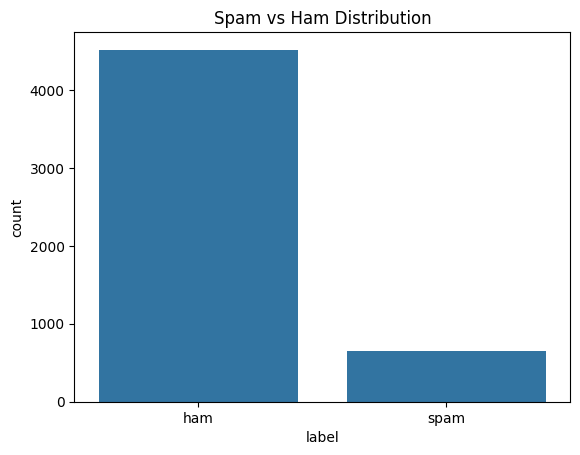

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='label',
    data=df
)

plt.title("Spam vs Ham Distribution")
plt.show()

### Visualize Class Distribution

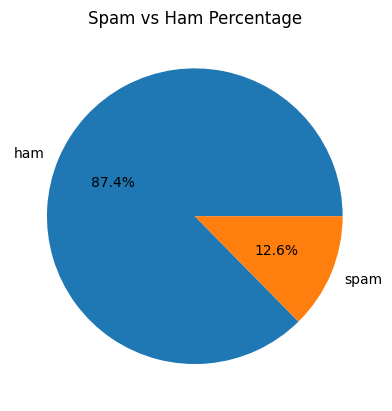

In [9]:
df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Spam vs Ham Percentage")
plt.ylabel('')
plt.show()

# CREATE EXTRA FEATURES
### Message Length

In [10]:
df['message_length'] = df['message'].apply(len)

df.head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


### PLOT MESSAGE LENGTH

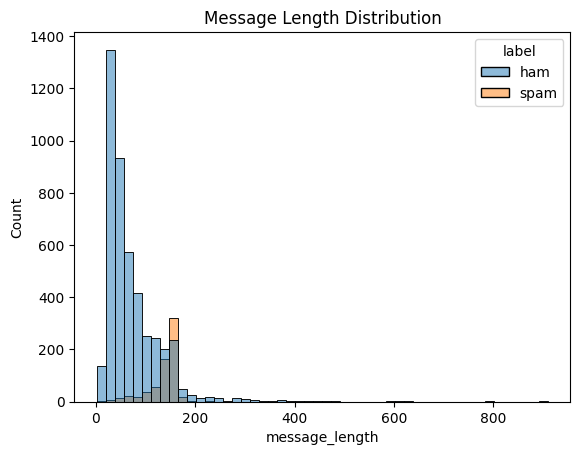

In [11]:
sns.histplot(
    data=df,
    x='message_length',
    hue='label',
    bins=50
)

plt.title("Message Length Distribution")
plt.show()

# LABEL ENCODING

### Convert:

ham → 0
spam → 1

In [12]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

In [13]:
df.head()

,label,message,message_length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


# TEXT CLEANING

### IMPORT

In [14]:
import re

### Create function:

In [ ]:
def clean_text(text):

    text = text.lower()

    text = re.sub(
        r'[^a-zA-Z0-9\s]',
        '',
        text
    )

    return text

### APPLY

In [17]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(
        r'[^a-zA-Z0-9\s]',
        '',
        text
    )
    return text

df['message'] = df['message'].apply(
    clean_text
)

# TF-IDF VECTORIZATION

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

### TRANSFORM TEXT

In [20]:
X = vectorizer.fit_transform(
    df['message']
)

y = df['label']

### VERIFY

In [21]:
print(X.shape)

(5169, 9541)


# TRAIN TEST SPLIT

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# TRAIN NAIVE BAYES

In [25]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(
    X_train,
    y_train
)

nb_pred = nb.predict(X_test)

# EVALUATE NAIVE BAYES

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("NAIVE BAYES RESULTS")
print("-" * 30)

print(
    "Accuracy:",
    accuracy_score(y_test, nb_pred)
)

print(
    "Precision:",
    precision_score(y_test, nb_pred)
)

print(
    "Recall:",
    recall_score(y_test, nb_pred)
)

print(
    "F1 Score:",
    f1_score(y_test, nb_pred)
)

NAIVE BAYES RESULTS
------------------------------
Accuracy: 0.9545454545454546
Precision: 1.0
Recall: 0.6642857142857143
F1 Score: 0.7982832618025751


# TRAIN LOGISTIC REGRESSION

In [27]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

# EVALUATE LOGISTIC REGRESSION

In [28]:
print("LOGISTIC REGRESSION RESULTS")
print("-" * 30)

print(
    "Accuracy:",
    accuracy_score(y_test, lr_pred)
)

print(
    "Precision:",
    precision_score(y_test, lr_pred)
)

print(
    "Recall:",
    recall_score(y_test, lr_pred)
)

print(
    "F1 Score:",
    f1_score(y_test, lr_pred)
)

LOGISTIC REGRESSION RESULTS
------------------------------
Accuracy: 0.9545454545454546
Precision: 0.9696969696969697
Recall: 0.6857142857142857
F1 Score: 0.803347280334728


# COMPARE BOTH MODELS

In [29]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred)
    ],
    "Precision": [
        precision_score(y_test, nb_pred),
        precision_score(y_test, lr_pred)
    ],
    "Recall": [
        recall_score(y_test, nb_pred),
        recall_score(y_test, lr_pred)
    ],
    "F1 Score": [
        f1_score(y_test, nb_pred),
        f1_score(y_test, lr_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.954545,1.000000,0.664286,0.798283
1,Logistic Regression,0.954545,0.969697,0.685714,0.803347


# CONFUSION MATRIX (NAIVE BAYES)

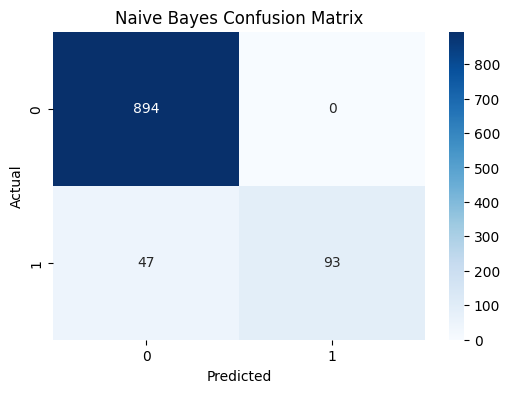

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(
    y_test,
    nb_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Naive Bayes Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# CONFUSION MATRIX (LOGISTIC REGRESSION)

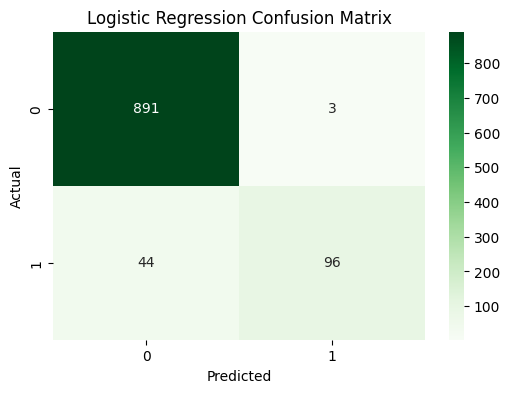

In [31]:
cm_lr = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# CLASSIFICATION REPORT

### Naive Bayes

In [32]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        nb_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       894
           1       1.00      0.66      0.80       140

    accuracy                           0.95      1034
   macro avg       0.98      0.83      0.89      1034
weighted avg       0.96      0.95      0.95      1034



### Logistic Regression

In [33]:
print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       894
           1       0.97      0.69      0.80       140

    accuracy                           0.95      1034
   macro avg       0.96      0.84      0.89      1034
weighted avg       0.96      0.95      0.95      1034



# SAVE THE BEST MODEL

In [34]:
import pickle

pickle.dump(
    lr,
    open(
        "spam_model.pkl",
        "wb"
    )
)

pickle.dump(
    vectorizer,
    open(
        "vectorizer.pkl",
        "wb"
    )
)

# TEST SAVED MODEL

In [35]:
loaded_model = pickle.load(
    open(
        "spam_model.pkl",
        "rb"
    )
)

loaded_vectorizer = pickle.load(
    open(
        "vectorizer.pkl",
        "rb"
    )
)

# PREDICTION SCRIPT

CREATING A NEW FILE

In [36]:
%%writefile predict.py

import pickle

model = pickle.load(
    open(
        "spam_model.pkl",
        "rb"
    )
)

vectorizer = pickle.load(
    open(
        "vectorizer.pkl",
        "rb"
    )
)

message = input(
    "Enter your message: "
)

message_vector = vectorizer.transform(
    [message]
)

prediction = model.predict(
    message_vector
)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Ham Message")

Writing predict.py


In [ ]:
import pickle

model = pickle.load(
    open(
        "spam_model.pkl",
        "rb"
    )
)

vectorizer = pickle.load(
    open(
        "vectorizer.pkl",
        "rb"
    )
)

message = input(
    "Enter your message: "
)

message_vector = vectorizer.transform(
    [message]
)

prediction = model.predict(
    message_vector
)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Ham Message")